In [2]:
# Install the package if you haven't already
!pip install --upgrade python-dotenv google-genai 

  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached websockets-16.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (6.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached cryptography-46.0.5-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (5.7 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 k

In [5]:
!pip install --upgrade pillow

  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.0 MB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Explicitly load the .env file into the notebook's environment
from dotenv import load_dotenv
import os

load_dotenv()

# Quick test to confirm it worked (should print 'True')
print("API Key loaded:", "GEMINI_API_KEY" in os.environ)

API Key loaded: True


In [6]:
from google import genai
from PIL import Image

client = genai.Client()
image = Image.open('../testcases/test-client_00.jfif')

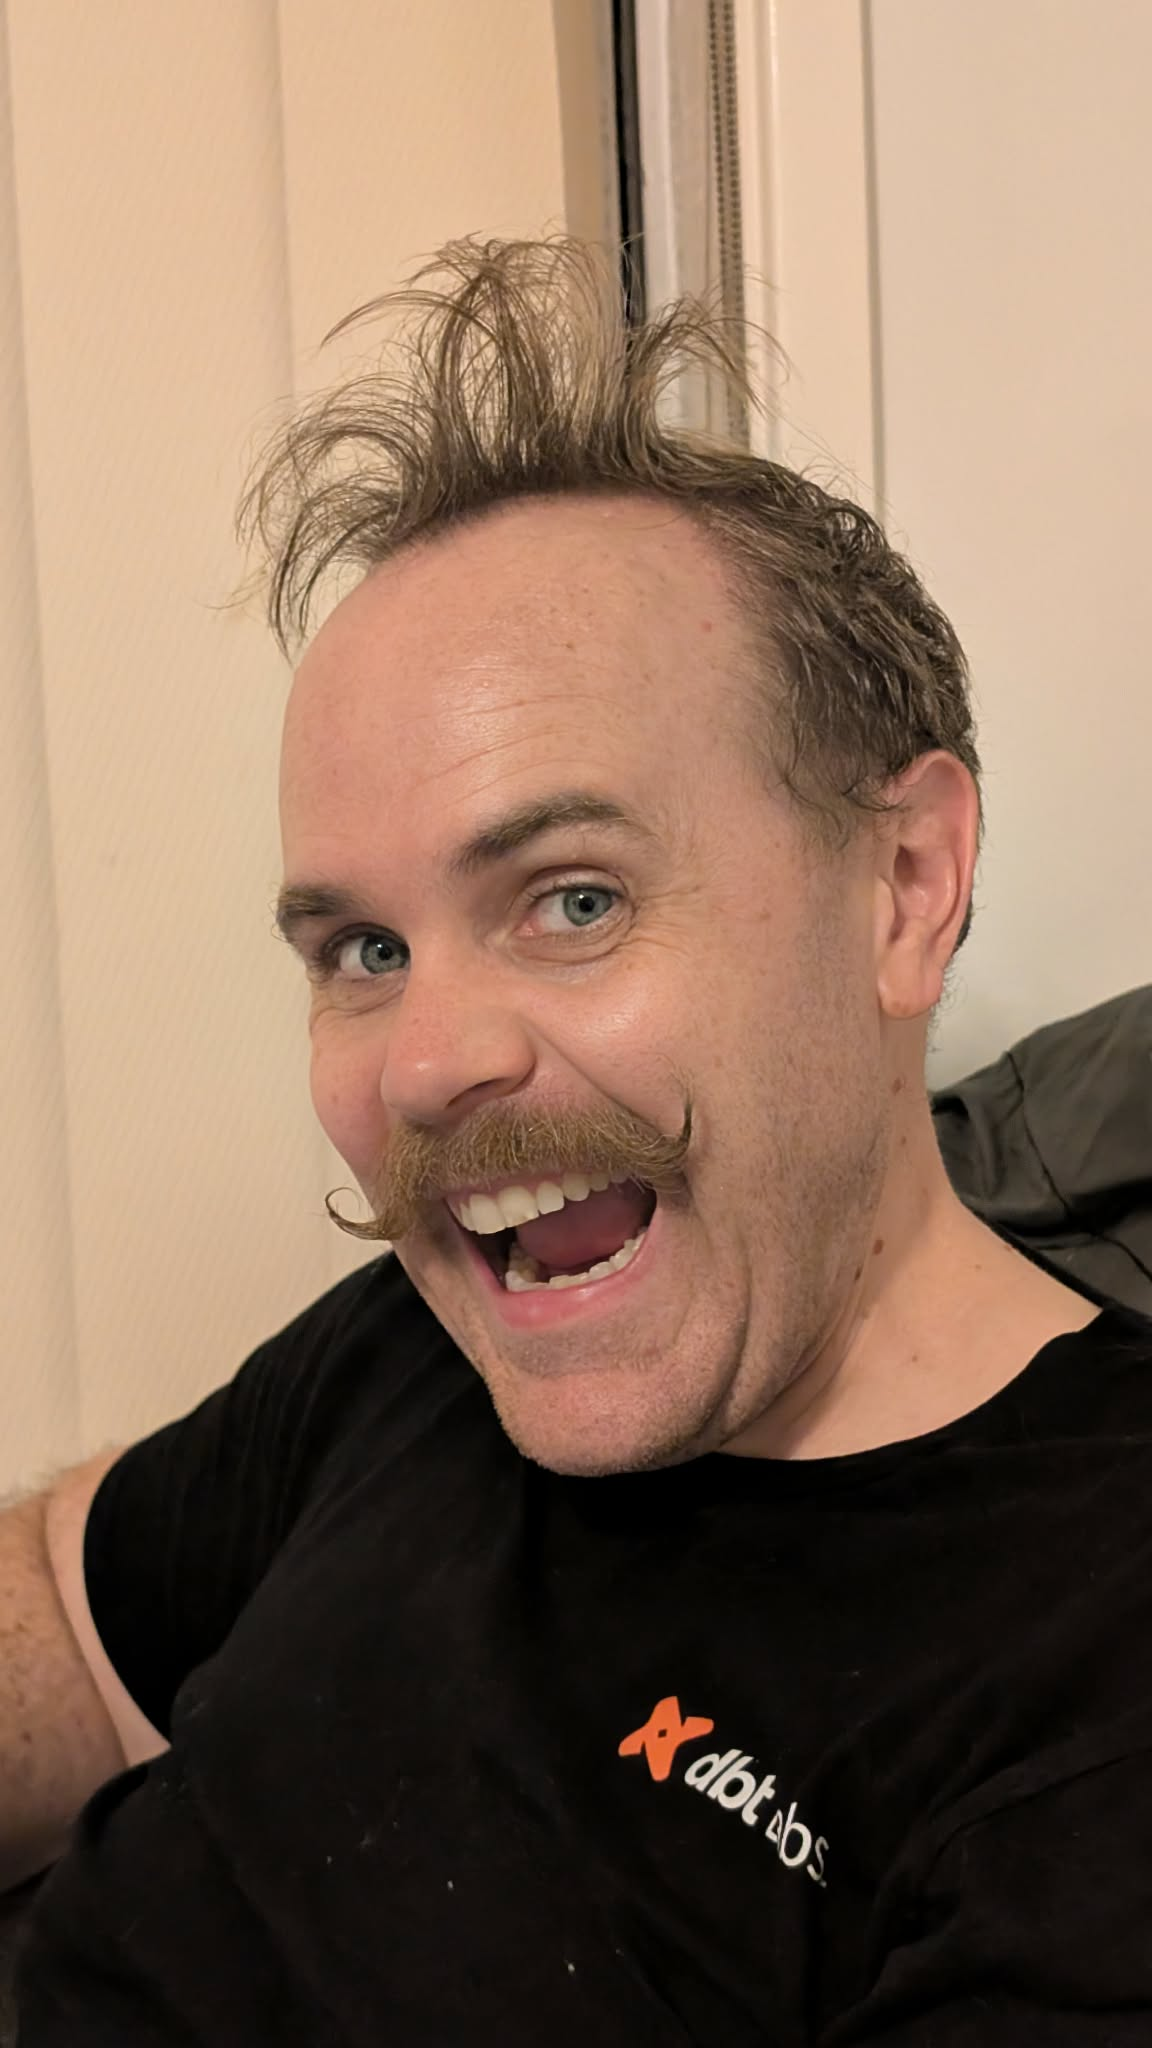

In [10]:
from IPython.display import display
display(image)

In [24]:
from google.genai import types
# Read raw bytes to bypass the PIL MIME-type bug associated with jfif files
with open('../testcases/test-client_00.jfif', 'rb') as f:
    image_bytes = f.read()

response = client.models.generate_content(
    model="gemini-2.5-flash", 
    contents=[
        "Client wants Scandi blonde. Assess the starting level in this photo.",
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/jpeg' # Forcing this fixes your ValueError
        )
    ]
)

print("\n--- Model Assessment ---")
print(response.text)


--- Model Assessment ---
Based on the provided images, here's an assessment of the client's starting hair level:

**Starting Hair Level Assessment:**

The client's natural hair color appears to be a **Level 5 (Light Brown)**.

**Observations to support this:**
*   **Hair on Top and Sides:** The bulk of the hair, visible in the original image and the cropped sections of the scalp, is a clear brown, not dark but definitely not in the blonde spectrum yet. It has a visible warmth to it, characteristic of light brown.
*   **Moustache and Eyebrows:** These are excellent indicators of natural pigment. His moustache is a distinct medium golden-brown, and his eyebrows are also a clear medium-brown. These align perfectly with a Level 5 natural base, which often carries warm (golden/red-orange) undertones.
*   **Overall Impression:** The hair is lighter than a typical medium brown (Level 4) but still definitively brown, placing it firmly in the Level 5 category.

**Implications for Scandi Blonde

In [ ]:
## for later
# from PIL import Image

# # Open the heavy generated PNG
# img = Image.open('../assets/astro_cool_hair.png')

# # Convert to RGB (removes transparency) and save as a compressed JPEG
# img.convert('RGB').save('../assets/astro_cool_hair-small.jpg', 'JPEG', optimize=True, quality=80)

FileNotFoundError: [Errno 2] No such file or directory: '../assets/astro_cool_hair.png'